In [3]:
from datasets import load_dataset

raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

def dataset_split_to_text(split):
    return "\n".join(raw[split]["text"])

train_text = dataset_split_to_text("train")
val_text = dataset_split_to_text("validation") 
test_text = dataset_split_to_text("test")

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
from nltk import word_tokenize, sent_tokenize
import gc
import torch
from torch import tensor
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from datasets import load_dataset

def load_data(split_name):
    """Return the full text of a WikiText-2 split as one string."""
    return "\n".join(raw_dataset[split_name]["text"])

def clean_data(data):
    data = re.sub(r'@-@', '-', data)
    data = re.sub(r'@\.@', '.', data)
    data = re.sub(r'@,@', ',', data)
    repl = ''
    data = re.sub('\(', repl, data)
    data = re.sub('\)', repl, data)
    for pattern in set(re.findall("=.*=", data)):
        data = re.sub(pattern, repl, data)
    for pattern in set(re.findall("<unk>", data)):
        data = re.sub(pattern, repl, data)
    for pattern in set(re.findall(r"[^\w ]", data)):
        repl = ''
        if pattern == '-':
            repl = ''
        if pattern != '.' and pattern != "\'":
            data = re.sub("\\" + pattern, repl, data)
    return data

def corpus_stats(splits, top_n=10):
    stats = {}
    all_words = set()
    top_words = {}
    for split_name in splits:
        raw = load_data(split_name)
        cleaned = clean_data(raw)
        tokens = cleaned.split()
        split_vocab = set(tokens)
        all_words.update(split_vocab)
        counts = Counter(tokens)
        top_words[split_name] = counts.most_common(top_n)

        stats[split_name] = {
            'num_tokens': len(tokens),
            'vocab_size': len(split_vocab)
        }

    stats_df = pd.DataFrame(stats).T[['num_tokens', 'vocab_size']]

    print("Corpus statistics: ")
    print(stats_df)
    print(f"\nCombined vocabulary size across all splits: {len(all_words)}")
    for split_name in splits:
        print(f"\nTop {top_n} most frequent words in {split_name}: ")
        for word, count in top_words[split_name]:
            print(f" {word}: {count}")

    return stats_df, len(all_words), top_words

raw_dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

splits = ["train", "validation", "test"]
stats_df, combined_vocab, top_words = corpus_stats(splits, top_n=10)

Corpus statistics: 
            num_tokens  vocab_size
train          1815485       75936
validation      190396       19681
test            214534       20866

Combined vocabulary size across all splits: 83855

Top 10 most frequent words in train: 
 the: 113006
 .: 76577
 of: 56603
 and: 49807
 in: 39384
 to: 39132
 a: 34225
 was: 20985
 The: 17509
 that: 14134

Top 10 most frequent words in validation: 
 the: 12611
 .: 8033
 of: 5880
 and: 5254
 in: 4254
 to: 4123
 a: 3439
 was: 2324
 The: 2074
 on: 1511

Top 10 most frequent words in test: 
 the: 13989
 .: 9440
 of: 6731
 and: 5780
 to: 4725
 in: 4495
 a: 3786
 was: 2575
 The: 2066
 on: 1610


In [81]:
def split_data(data, num_sentences = -1):

    #sentence tokenization
    if num_sentences == -1:
        sentences = sent_tokenize(data)
    else:
        sentences = sent_tokenize(data)[:num_sentences]

    #word tokenization
    words = set()
    for sent in sentences:
        for word in str.split(sent, ' '):
            words.add(word)
    words = list(words)

    #add empty string (padding zeros) in list of words to avoid confusion while padding
    words.insert(0, "")

    return sentences, words

In [82]:
def convert_data(sentences, words, seq_len, word_ind=None, ind_word=None,
                  pad_token='<pad>', unk_token='<unk>'):
    # ensure special tokens exist in the vocabulary
    words = list(dict.fromkeys(words))   # de-duplicates while preserving order
    if pad_token not in words:
        words.append(pad_token)
    if unk_token not in words:
        words.append(unk_token)

    # build lookup dicts once, or reuse ones passed in (e.g. from train)
    if word_ind is None or ind_word is None:
        word_ind = {w: i for i, w in enumerate(words)}
        ind_word = {i: w for i, w in enumerate(words)}

    pad_idx = word_ind[pad_token]
    unk_idx = word_ind[unk_token]

    # build (predictor window, next word) pairs via a sliding window
    predictors, class_labels = [], []
    for sentence in sentences:
        tokens = [t for t in sentence.split(' ') if t != '']
        for j in range(1, len(tokens)):
            start = max(0, j - seq_len)
            predictors.append(tokens[start:j])
            class_labels.append(tokens[j])

    # left-pad each window with pad_token up to seq_len
    pad_predictors = []
    for seq in predictors:
        pad_len = seq_len - len(seq)
        pad_predictors.append([pad_token] * pad_len + seq)

    # encode to indices, falling back to <unk> for unseen words
    encoded_predictors = [
        [word_ind.get(w, unk_idx) for w in seq] for seq in pad_predictors
    ]
    encoded_labels = [word_ind.get(w, unk_idx) for w in class_labels]

    pad_predictors_tensor = torch.stack(
        [torch.tensor(seq, dtype=torch.long) for seq in encoded_predictors]
    )
    class_labels_tensor = torch.tensor(encoded_labels, dtype=torch.long)

    return pad_predictors_tensor, class_labels_tensor, word_ind, ind_word

In [83]:
class LSTM(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size):
        super(LSTM, self).__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.padding_idx = padding_idx
        self.hidden_size = hidden_size
        self.dropout = Dropout_p
        self.batch_size = batch_size
        # add Embedding Layer
        self.Embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=padding_idx)  # fixed: was hardcoded 0
        # add LSTM Layer
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers=1, batch_first=True)
        # add Dropout Layer
        self.dropout = nn.Dropout(Dropout_p)
        # add fully connected dense Layer
        self.FC = nn.Linear(hidden_size, num_embeddings)
    def init_hidden(self, batch_size):
        state_h = torch.zeros(1, batch_size, self.hidden_size)
        state_c = torch.zeros(1, batch_size, self.hidden_size)
        return (state_h, state_c)
    def forward(self, input_sequence, state_h, state_c):
        Embed_input = self.Embedding(input_sequence)
        output, (state_h, state_c) = self.lstm(Embed_input, (state_h, state_c))
        logits = self.FC(output[:, -1, :])
        return logits, (state_h, state_c)
    def topk_sampling(self, logits, topk):
        logits_softmax = F.softmax(logits, dim=1)
        values, indices = torch.topk(logits_softmax[0], k=topk)
        choices = indices.tolist()
        sampling = random.sample(choices, 1)
        return ind_word[sampling[0]]


In [84]:
def get_batch(pad_predictors, class_labels, batch_size):
    for i in range(0, len(pad_predictors), batch_size):
        if i + batch_size < len(pad_predictors):
            yield pad_predictors[i:i+batch_size], class_labels[i:i+batch_size]

In [85]:
import time

def train_lstm(pad_predictors, class_labels, n_vocab, embedding_dim, padding_idx, 
                hidden_size, Dropout_p, batch_size, lr, num_epochs=10):
    model = LSTM(n_vocab, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size)
    criterion = nn.CrossEntropyLoss(ignore_index=padding_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    epoch_times = []
    epoch_losses = []
    total_start = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        state_h, state_c = model.init_hidden(batch_size)
        
        total_loss = 0
        for x, y in get_batch(pad_predictors, class_labels, batch_size):
            model.train()
            state_h = state_h.detach()
            state_c = state_c.detach()
            
            logits, (state_h, state_c) = model(x, state_h, state_c)
            loss = criterion(logits, y)
            loss_value = loss.item()
            total_loss += len(x) * loss_value
            
            model.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
        
        total_loss /= len(pad_predictors)
        epoch_elapsed = time.time() - epoch_start
        epoch_times.append(epoch_elapsed)
        epoch_losses.append(total_loss)
        
        print(f"Epoch[{epoch+1} / {num_epochs}] Loss: {total_loss}, perplexity: {np.exp(total_loss)}, time: {epoch_elapsed:.2f}s")
        
        gen_text = generate(model, init='The', sent_len=100, topk=5)
        print(f"Text generated after epoch {epoch}:\n{gen_text}\n")
    
    total_elapsed = time.time() - total_start
    print(f"\nTotal training time: {total_elapsed:.2f}s ({total_elapsed/60:.2f} min)")
    print(f"Avg time per epoch: {np.mean(epoch_times):.2f}s")
    
    return model, total_loss, epoch_times, epoch_losses, total_elapsed

In [86]:
import inspect
print(inspect.getsource(LSTM.topk_sampling))


    def topk_sampling(self, logits, topk):
        logits_softmax = F.softmax(logits, dim=1)
        values, indices = torch.topk(logits_softmax[0], k=topk)
        choices = indices.tolist()
        sampling = random.sample(choices, 1)
        return ind_word[sampling[0]]



GRU: 2 gates, no cell state, trains faster
LSTM: 3 gates, one cell state

In [87]:
# only one hidden state, not (h, c)
class GRU(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size):
        super(GRU, self).__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.padding_idx = padding_idx
        self.hidden_size = hidden_size
        self.dropout = Dropout_p
        self.batch_size = batch_size
        self.Embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=padding_idx)  # fixed: was hardcoded 0
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(Dropout_p)
        self.FC = nn.Linear(hidden_size, num_embeddings)
    def init_hidden(self, batch_size):
        state_h = torch.zeros(1, batch_size, self.hidden_size)
        return state_h  # one state, no cell state
    def forward(self, input_sequence, state_h):
        Embed_input = self.Embedding(input_sequence)
        output, state_h = self.gru(Embed_input, state_h)
        logits = self.FC(output[:, -1, :])
        return logits, state_h
    def topk_sampling(self, logits, topk):
        logits_softmax = F.softmax(logits, dim=1)
        values, indices, = torch.topk(logits_softmax[0], k=topk)
        choices = indices.tolist()
        sampling = random.sample(choices, 1)
        return ind_word[sampling[0]]

In [88]:
def train_gru(pad_predictors, class_labels, n_vocab, embedding_dim, padding_idx, 
              hidden_size, Dropout_p, batch_size, lr, num_epochs=10):
    model = GRU(n_vocab, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size)
    criterion = nn.CrossEntropyLoss(ignore_index=padding_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    epoch_times = []
    epoch_losses = []
    total_start = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        state_h = model.init_hidden(batch_size)  # GRU: single state, not a tuple
        
        total_loss = 0
        for x, y in get_batch(pad_predictors, class_labels, batch_size):
            model.train()
            state_h = state_h.detach()
            
            logits, state_h = model(x, state_h)  # GRU forward takes/returns one state
            loss = criterion(logits, y)
            loss_value = loss.item()
            total_loss += len(x) * loss_value
            
            model.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
        
        total_loss /= len(pad_predictors)
        epoch_elapsed = time.time() - epoch_start
        epoch_times.append(epoch_elapsed)
        epoch_losses.append(total_loss)
        
        print(f"Epoch[{epoch+1} / {num_epochs}] Loss: {total_loss}, perplexity: {np.exp(total_loss)}, time: {epoch_elapsed:.2f}s")
        
        gen_text = generate(model, init='The', sent_len=100, topk=5)
        print(f"Text generated after epoch {epoch}:\n{gen_text}\n")
    
    total_elapsed = time.time() - total_start
    print(f"\nTotal training time: {total_elapsed:.2f}s ({total_elapsed/60:.2f} min)")
    print(f"Avg time per epoch: {np.mean(epoch_times):.2f}s")
    
    return model, total_loss, epoch_times, epoch_losses, total_elapsed

In [117]:
class TransformerModel(nn.Module):
    def __init__(self, n_vocab, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size,
                 nhead=4, nlayers=2, max_len=512):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Embedding(n_vocab, embedding_dim, padding_idx=padding_idx)
        self.pos_embedding = nn.Embedding(max_len, embedding_dim)
        self.drop = nn.Dropout(Dropout_p)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=hidden_size,
            dropout=Dropout_p,
            batch_first=True,   
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.fc = nn.Linear(embedding_dim, n_vocab)

        self.padding_idx = padding_idx

    def forward(self, x):
        # x: (batch, seq_len)
        bsz, seq_len = x.shape
        device = x.device

        pos_ids = torch.arange(seq_len, device=device).unsqueeze(0).expand(bsz, seq_len)
        e = self.drop(self.embedding(x) + self.pos_embedding(pos_ids))

        # causal mask: position i can't attend to positions > i
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(device)

        # padding mask: True where x is padding, so attention ignores those positions
        padding_mask = (x == self.padding_idx)

        out = self.encoder(e, mask=causal_mask, src_key_padding_mask=padding_mask, is_causal=True)
        out = torch.nan_to_num(out, nan=0.0)  # zero out NaNs from fully-masked rows
    
        logits = self.fc(out[:, -1, :])  # predict next word from the last position, matches your LSTM/GRU's use of the final timestep
        return logits, None
 
    def topk_sampling(self, logits, topk):
        logits_softmax = F.softmax(logits, dim=1)
        values, indices=torch.topk(logits_softmax[0], k=topk)
        choices=indices.tolist()
        sampling=random.sample(choices, 1)

        return ind_word[sampling[0]]


In [118]:
transformer_model = torch.load(results['transformer']['model_path'], weights_only=False)


In [101]:
# no hidden state, needs positiaonl encoding, masking, etc
def train_transformer(pad_predictors, class_labels, n_vocab, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size, lr, num_epochs=10):
    model = TransformerModel(n_vocab, embedding_dim, padding_idx, hidden_size, Dropout_p, batch_size)
    criterion = nn.CrossEntropyLoss(ignore_index=padding_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_times = []
    epoch_losses = []
    total_start = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        total_loss = 0

        for x, y in get_batch(pad_predictors, class_labels, batch_size):
            model.train()
            logits, _ = model(x) # no state passed in

            loss = criterion(logits, y)
            loss_value = loss.item()
            total_loss += len(x) * loss_value

            model.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()

        total_loss /= len(pad_predictors)
        epoch_elapsed = time.time() - epoch_start
        epoch_times.append(epoch_elapsed)
        epoch_losses.append(total_loss)

        print(f"Epoch[{epoch+1} / {num_epochs}] Loss: {total_loss}, perplexity: {np.exp(total_loss)}, time: {epoch_elapsed:.2f}s")

        gen_text = generate_transformer(model, init='The', sent_len=100, topk=5)
        print(f"Text generated after epoch {epoch}:\n{gen_text}\n")

    total_elapsed = time.time() - total_start
    print(f"\nTotal training time: {total_elapsed:.2f}s")

    return model, total_loss, epoch_times, epoch_losses, total_elapsed

In [121]:
@torch.no_grad()
def evaluate(model, pad_predictors, class_labels, batch_size=200):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none') # per-example loss, not averaged

    total_loss = 0
    total_count = 0

    state = model.init_hidden(batch_size) if hasattr(model, "init_hidden") else None
    if isinstance(state, tuple):
        state = tuple(s.detach() for s in state)
    elif state is not None:
        state = state.detach()

    for x, y in get_batch(pad_predictors, class_labels, batch_size):
        if state is None:
            logits = model(x)            # transformer: no recurrent state
            if isinstance(logits, tuple):
                logits = logits[0]
        elif isinstance(state, tuple):
            logits, state = model(x, *state)       # lstm: (state_h, state_c)
            state = tuple(s.detach() for s in state)
        else:
            logits, state = model(x, state)     # gru: single state
            state = state.detach()

        losses = criterion(logits, y)  # shape (batch,)
        valid_mask = (x[:, 0] != model.padding_idx) if hasattr(model, 'padding_idx') else torch.ones_like(losses, dtype=torch.bool)
        losses = losses[valid_mask]

        total_loss += losses.sum().item()
        total_count += len(losses)
    

    total_loss /= total_count
    return total_loss, float(np.exp(total_loss))

In [145]:
pad_idx = results['word_ind']['<pad>']
print((val_class_labels == pad_idx).float().mean().item())
print((test_class_labels == pad_idx).float().mean().item())


0.0
0.0


In [103]:
def prepare_test_data(words, seq_len, num_sentences=6000):
    test_raw = load_data("test")
    data = clean_data(test_raw[:])
    sentences, _ = split_data(data, num_sentences=num_sentences)
    pad_predictors, class_labels, _, _ = convert_data(
        sentences, words, seq_len, word_ind=word_ind, ind_word=ind_word
    )

    words = list(word_ind.keys())
    
    return convert_data(sentences, words, seq_len)


In [104]:
def generate(model, init, sent_len, topk):
    sentence = init
    is_lstm = isinstance(model, LSTM)
    is_gru = isinstance(model, GRU)
    for k in range(sent_len):
        model.eval()
        input_indices = []
        for word in str.split(sentence, " "):
            input_indices.append(word_ind.get(word, word_ind['<unk>']))
        if len(input_indices) < seq_len - 1:
            input_tensor = [word_ind['<pad>']] * (seq_len - len(input_indices) - 1)  # fixed: was hardcoded 0
            input_tensor.extend(input_indices)
        else:
            input_tensor = input_indices[-seq_len + 1:]
        input_tensor = torch.stack([torch.tensor(input_tensor)])
        if is_lstm:
            state_h, state_c = model.init_hidden(input_tensor.shape[0])
            out, (state_h, state_c) = model(input_tensor, state_h, state_c)
        elif is_gru:
            state_h = model.init_hidden(input_tensor.shape[0])
            out, state_h = model(input_tensor, state_h)
        else:
            out, _ = model(input_tensor)
        word = model.topk_sampling(out, topk)
        if word != '' and word != str.split(sentence, ' ')[-1]:
            sentence = sentence + " " + word
    return sentence


In [105]:
def generate_transformer(model, init, sent_len, topk):
    sentence = init
    for k in range(sent_len):
        model.eval()
        input_indices = [word_ind.get(word, word_ind['<unk>']) for word in sentence.split(" ")]
        if len(input_indices) < seq_len - 1:
            input_tensor = [word_ind['<pad>']] * (seq_len - len(input_indices) - 1)  # fixed: was hardcoded 0
            input_tensor.extend(input_indices)
        else:
            input_tensor = input_indices[-seq_len+1:]
        input_tensor = torch.tensor(input_tensor).unsqueeze(0)
        with torch.no_grad():
            out, _ = model(input_tensor)
        word = model.topk_sampling(out, topk)
        if word != '' and word != sentence.split(' ')[-1]:
            sentence = sentence + " " + word
    return sentence

for model_name in ['lstm', 'gru', 'transformer']:
    print(f"\n{'='*80}\n[{model_name.upper()}]\n{'='*80}")
    print(results[model_name]['generated'])


[LSTM]
The entire highway system in the region of a new badge in September 2006 and the second season premiere . was the only feature in late 1980s in June . ' was the monarch could have had the right side not the right to take control the first down with their sons the rear superstructure were bricked for the time and then to reduce to go ahead . as punk rock Department of a new badge but still loved in a short place during its time construction and was made by some Arkansans . and are known for their hardiness

[GRU]
The first down M 37 yard unsportsmanlike convoy were removed from a fire hydrant . while ' and ran to the south west coast of Parliament in 1937 by plate and the National Highway Museum of Mount Erebus and in the middle . who were theoretically in the middle . while it has been made in other cultures . and ' 80s ' . ' defense ' Apparatus in 2009 and the United Nations . who was a notoriously of the state of the state is to protect a product or the basis for a new point 

In [95]:
def main():
    global word_ind, ind_word, seq_len
    print('word_ind' in globals())
    if 'word_ind' in globals():
        print(len(word_ind))
        print('<unk>' in word_ind)
        print(list(word_ind.keys())[:5])
    train = load_data("train")
    val = load_data("validation")
    data = clean_data(train[:])
    sentences, words = split_data(data, num_sentences=25000)
    pad_predictors, class_labels, word_ind, ind_word = convert_data(sentences, words, seq_len)

    words = list(word_ind.keys())
    print("Number of input sequences: ", len(pad_predictors))
    val_data = clean_data(val[:])
    val_sentences, _ = split_data(val_data, num_sentences=5000)
    val_pad_predictors, val_class_labels, _, _ = convert_data(
        val_sentences, words, seq_len, word_ind=word_ind, ind_word=ind_word
    )
    print("n_vocab used for training:", len(words))
    print("max index in word_ind:", max(word_ind.values()))
    print("word_ind['<pad>']:", word_ind['<pad>'])
    print("word_ind['<unk>']:", word_ind['<unk>'])
    print("max index in train pad_predictors:", pad_predictors.max().item())
    print("max index in val pad_predictors:", val_pad_predictors.max().item())
    print("min index in val pad_predictors:", val_pad_predictors.min().item())

    results = {}
    # lstm_model
    lstm_model, lstm_loss, lstm_epoch_times, lstm_epoch_losses, lstm_total_time = train_lstm(
        pad_predictors, class_labels, n_vocab=len(words), embedding_dim=100,
        padding_idx=word_ind['<pad>'], hidden_size=128, Dropout_p=0.1, batch_size=200, lr=0.001
    )
    lstm_val_loss, lstm_val_ppl = evaluate(lstm_model, val_pad_predictors, val_class_labels, batch_size=200)
    lstm_generated = generate(lstm_model, init='The', sent_len=100, topk=5)
    torch.save(lstm_model, "./LSTM_model.pt")
    results['lstm'] = {
        'model_path': "./LSTM_model.pt", 'train_loss': lstm_loss, 'val_loss': lstm_val_loss, 'val_ppl': lstm_val_ppl,
        'epoch_times': lstm_epoch_times, 'epoch_losses': lstm_epoch_losses,
        'total_time': lstm_total_time, 'generated': lstm_generated,
    }
    print("lstm_model embedding size:", lstm_model.Embedding.num_embeddings)

    # gru_model
    gru_model, gru_loss, gru_epoch_times, gru_epoch_losses, gru_total_time = train_gru(
        pad_predictors, class_labels, n_vocab=len(words), embedding_dim=100,
        padding_idx=word_ind['<pad>'], hidden_size=128, Dropout_p=0.1, batch_size=200, lr=0.001
    )
    gru_val_loss, gru_val_ppl = evaluate(gru_model, val_pad_predictors, val_class_labels, batch_size=200)
    gru_generated = generate(gru_model, init='The', sent_len=100, topk=5)
    torch.save(gru_model, "./GRU_model.pt")
    results['gru'] = {
        'model_path': "./GRU_model.pt", 'train_loss': gru_loss, 'val_loss': gru_val_loss, 'val_ppl': gru_val_ppl,
        'epoch_times': gru_epoch_times, 'epoch_losses': gru_epoch_losses,
        'total_time': gru_total_time, 'generated': gru_generated,
    }

    # transformer_model
    transformer_model, transformer_loss, transformer_epoch_times, transformer_epoch_losses, transformer_total_time = train_transformer(
        pad_predictors, class_labels, n_vocab=len(words), embedding_dim=100,
        padding_idx=word_ind['<pad>'], hidden_size=128, Dropout_p=0.1, batch_size=200, lr=0.001
    )
    transformer_val_loss, transformer_val_ppl = evaluate(transformer_model, val_pad_predictors, val_class_labels, batch_size=200)
    transformer_generated = generate_transformer(transformer_model, init='The', sent_len=100, topk=5)
    torch.save(transformer_model, "./Transformer_model.pt")
    results['transformer'] = {
        'model_path': "./Transformer_model.pt", 'train_loss': transformer_loss, 'val_loss': transformer_val_loss, 'val_ppl': transformer_val_ppl,
        'epoch_times': transformer_epoch_times, 'epoch_losses': transformer_epoch_losses,
        'total_time': transformer_total_time, 'generated': transformer_generated,
    }
    results['word_ind'] = word_ind
    results['ind_word'] = ind_word
    results['words'] = words

    return results

In [96]:
results = main()
print(results['word_ind']['<pad>'])


True
39996
True
['', 'impressed', 'numbering', 'frock', 'Unyanyembe']
Number of input sequences:  560625
n_vocab used for training: 39996
max index in word_ind: 39995
word_ind['<pad>']: 39994
word_ind['<unk>']: 39995
max index in train pad_predictors: 39994
max index in val pad_predictors: 39995
min index in val pad_predictors: 1
Epoch[1 / 10] Loss: 7.462572091739446, perplexity: 1741.6219126340093, time: 125.03s
Text generated after epoch 0:
The first of the first . of the first of the state . of her own . and in this of his first and was used as a number to its second . and its second time was not to take to be used as the fort was a second in which a second and a new of its first in an important to a large to have to take . the game of her and a new series of her and the original . in a new . and was the same and a few 's first of two

Epoch[2 / 10] Loss: 6.479626835171328, perplexity: 651.7276990331875, time: 131.03s
Text generated after epoch 1:
The entire freeway of a new series 

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/torch/nn/modules/transformer.py:429: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch[1 / 10] Loss: 7.473543991718271, perplexity: 1760.8360289884015, time: 163.27s
Text generated after epoch 0:
The numbering frock Unyanyembe impressed . and that it was to take in the freeway in November to a series . in South to a series of . in December the state to this and the South to take in December to their in the South of an section to be by . to a state and a new and in November and in the South and was in a of . and in a number and the first was in 2004 . to its in a state of which were to the United States and the South was

Epoch[2 / 10] Loss: 6.623979889052103, perplexity: 752.9357426647732, time: 164.70s
Text generated after epoch 1:
The Unyanyembe frock impressed numbering in the Grand of M to take . in a few to be used to take that was a new first . in November the freeway to be used as it to do to do . and the state was also used as an attack for an interchange . in November 2004 and the United States . was also a large attack to do in December and is used by an 

In [98]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shannonchiang/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [137]:
# Build test set
test = load_data("test")
test_data = clean_data(test[:])
test_sentences, _ = split_data(test_data, num_sentences=5000)
test_pad_predictors, test_class_labels, _, _ = convert_data(
    test_sentences, results['words'], seq_len,
    word_ind=results['word_ind'], ind_word=results['ind_word']
)

# Evaluate all three models on test set
lstm_test_loss, lstm_test_ppl = evaluate(lstm_model, test_pad_predictors, test_class_labels, batch_size=200)
gru_test_loss, gru_test_ppl = evaluate(gru_model, test_pad_predictors, test_class_labels, batch_size=200)
transformer_test_loss, transformer_test_ppl = evaluate(transformer_model, test_pad_predictors, test_class_labels, batch_size=200)

results['lstm']['test_loss'] = lstm_test_loss
results['lstm']['test_ppl'] = lstm_test_ppl
results['gru']['test_loss'] = gru_test_loss
results['gru']['test_ppl'] = gru_test_ppl
results['transformer']['test_loss'] = transformer_test_loss
results['transformer']['test_ppl'] = transformer_test_ppl

print(f"LSTM  test_loss={lstm_test_loss:.4f} test_ppl={lstm_test_ppl:.2f}")
print(f"GRU   test_loss={gru_test_loss:.4f} test_ppl={gru_test_ppl:.2f}")
print(f"Transformer test_loss={transformer_test_loss:.4f} test_ppl={transformer_test_ppl:.2f}")

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/torch/nn/modules/transformer.py:429: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


LSTM  test_loss=8.1722 test_ppl=3541.13
GRU   test_loss=8.1009 test_ppl=3297.38
Transformer test_loss=8.0304 test_ppl=3073.09


In [141]:
print(train_losses)
print(val_losses)
print(test_losses)

[4.210032224708311, 4.146769225079081, 4.921536929025299]
[8.146584084054002, 8.077787051528901, 8.040299526812833]
[8.172202002260036, 8.100884205676737, 8.030439157243984]


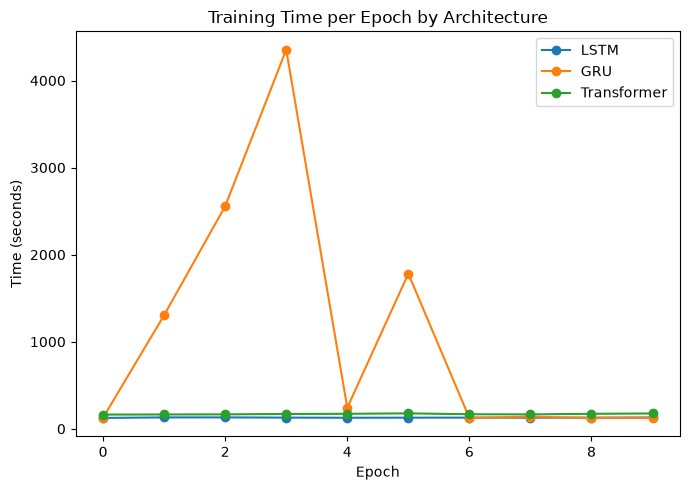

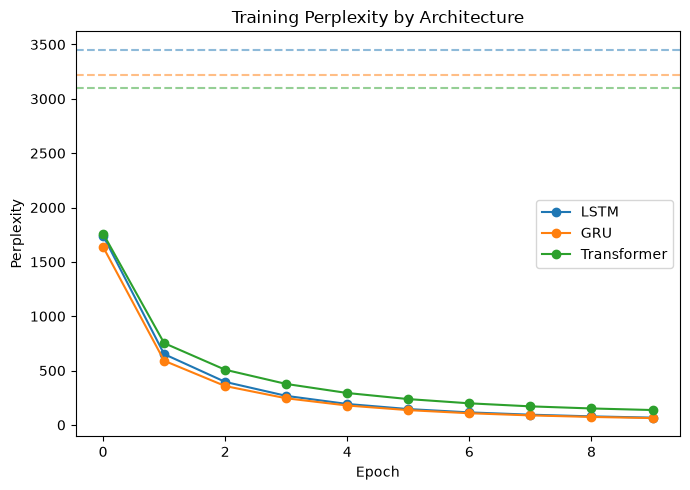

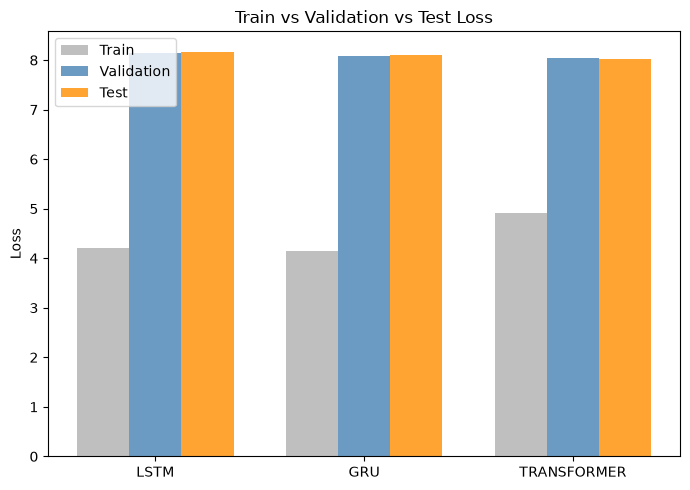

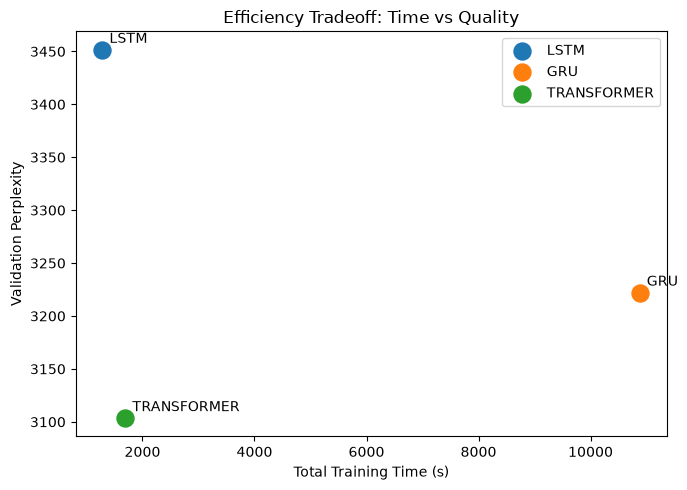

In [143]:
# Panel 1
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(results['lstm']['epoch_times'], label='LSTM', marker='o')
ax.plot(results['gru']['epoch_times'], label='GRU', marker='o')
ax.plot(results['transformer']['epoch_times'], label='Transformer', marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (seconds)')
ax.set_title('Training Time per Epoch by Architecture')
ax.legend()

fig.tight_layout()
fig.savefig('results/training_time_per_epoch_by_architecture.png', dpi=150, bbox_inches='tight')
plt.show()


# Panel 2
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(np.exp(results['lstm']['epoch_losses']), label='LSTM', marker='o', color='C0')
ax.plot(np.exp(results['gru']['epoch_losses']), label='GRU', marker='o', color='C1')
ax.plot(np.exp(results['transformer']['epoch_losses']), label='Transformer', marker='o', color='C2')

ax.axhline(results['lstm']['val_ppl'], color='C0', linestyle='--', alpha=0.5)
ax.axhline(results['gru']['val_ppl'], color='C1', linestyle='--', alpha=0.5)
ax.axhline(results['transformer']['val_ppl'], color='C2', linestyle='--', alpha=0.5)

ax.set_xlabel('Epoch')
ax.set_ylabel('Perplexity')
ax.set_title('Training Perplexity by Architecture')
ax.legend()

fig.tight_layout()
fig.savefig('results/training_ppl_with_val_ppl_as_dashed.png', dpi=150, bbox_inches='tight')
plt.show()


# Panel 3

fig, ax = plt.subplots(figsize=(7, 5))
models_list = ['lstm', 'gru', 'transformer']
x = np.arange(len(models_list))
width = 0.25
train_losses = [results[m]['epoch_losses'][-1] for m in models_list]
val_losses = [results[m]['val_loss'] for m in models_list]
test_losses = [results[m]['test_loss'] for m in models_list]
ax.bar(x - width, train_losses, width, label='Train', alpha=0.5, color='gray')
ax.bar(x, val_losses, width, label='Validation', alpha=0.8, color='steelblue')
ax.bar(x + width, test_losses, width, label='Test', alpha=0.8, color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models_list])
ax.set_ylabel('Loss')
ax.set_title('Train vs Validation vs Test Loss')
ax.legend()
fig.tight_layout()
fig.savefig('results/train_vs_validation_vs_test_loss.png', dpi=150, bbox_inches='tight')
plt.show()


# Panel 4
fig, ax = plt.subplots(figsize=(7, 5))

for m, c in zip(models_list, colors):
    total_time = results[m]['total_time']
    val_ppl = results[m]['val_ppl']

    ax.scatter(total_time, val_ppl, s=150, color=c, label=m.upper())
    ax.annotate(
        m.upper(),
        (total_time, val_ppl),
        textcoords='offset points',
        xytext=(5, 5)
    )

ax.set_xlabel('Total Training Time (s)')
ax.set_ylabel('Validation Perplexity')
ax.set_title('Efficiency Tradeoff: Time vs Quality')
ax.legend()

fig.tight_layout()
fig.savefig('results/time_vs_val_ppl.png', dpi=150, bbox_inches='tight')
plt.show()

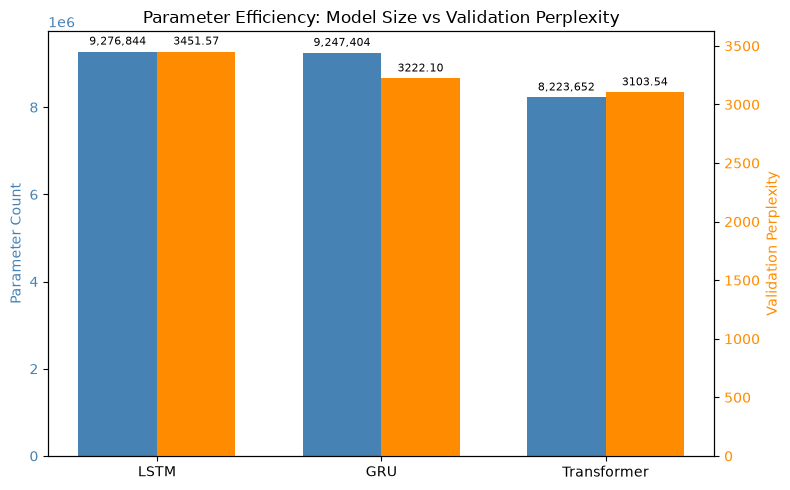

In [125]:
lstm_model = torch.load(results['lstm']['model_path'], weights_only=False)
gru_model = torch.load(results['gru']['model_path'], weights_only=False)
transformer_model = torch.load(results['transformer']['model_path'], weights_only=False)

param_counts = {
    'LSTM': sum(p.numel() for p in lstm_model.parameters()),
    'GRU': sum(p.numel() for p in gru_model.parameters()),
    'Transformer': sum(p.numel() for p in transformer_model.parameters()),
}
val_ppls = {
    'LSTM': results['lstm']['val_ppl'],
    'GRU': results['gru']['val_ppl'],
    'Transformer': results['transformer']['val_ppl'],
}

fig, ax1 = plt.subplots(figsize=(8, 5))
model_names = list(param_counts.keys())
x = np.arange(len(model_names))
width = 0.35

ax1.bar(x - width/2, [param_counts[m] for m in model_names], width, label='Parameters', color='steelblue')
ax1.set_ylabel('Parameter Count', color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar(x + width/2, [val_ppls[m] for m in model_names], width, label='Val Perplexity', color='darkorange')
ax2.set_ylabel('Validation Perplexity', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

for i, m in enumerate(model_names):
    ax1.annotate(f'{param_counts[m]:,}', (x[i]-width/2, param_counts[m]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)
    ax2.annotate(f'{val_ppls[m]:.2f}', (x[i]+width/2, val_ppls[m]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

plt.title('Parameter Efficiency: Model Size vs Validation Perplexity')
fig.tight_layout()
plt.savefig('param_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.11/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


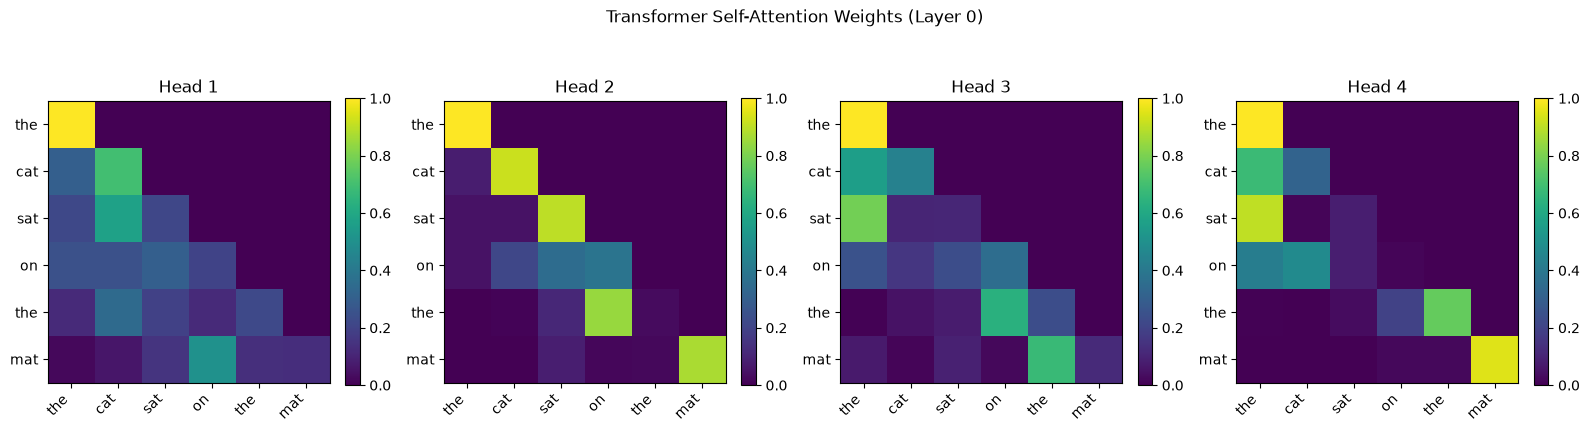

In [126]:
def get_attention_weights(model, sentence_tokens, layer_idx=0):
    model.eval()
    x = torch.tensor(sentence_tokens).unsqueeze(0)
    bsz, seq_len_local = x.shape
    device = x.device
    pos_ids = torch.arange(seq_len_local, device=device).unsqueeze(0).expand(bsz, seq_len_local)

    with torch.no_grad():
        e = model.embedding(x) + model.pos_embedding(pos_ids)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len_local).to(device)
        padding_mask = (x == word_ind['<pad>'])  # fixed: was hardcoded 0, now matches actual pad token

        out = e
        for i, layer in enumerate(model.encoder.layers):
            if i == layer_idx:
                _, attn_weights = layer.self_attn(
                    out, out, out,
                    attn_mask=causal_mask,
                    key_padding_mask=padding_mask,
                    need_weights=True,
                    average_attn_weights=False,
                )
                return attn_weights.squeeze(0)
            out = layer(out, src_mask=causal_mask, src_key_padding_mask=padding_mask)

sample_sentence = "the cat sat on the mat"  # replace with a real sentence from your training data
sample_tokens = [word_ind.get(w, word_ind['<unk>']) for w in sample_sentence.split()]
attn_weights = get_attention_weights(transformer_model, sample_tokens, layer_idx=0)

nhead = attn_weights.shape[0]
fig, axes = plt.subplots(1, nhead, figsize=(4*nhead, 4))
if nhead == 1:
    axes = [axes]
for h in range(nhead):
    im = axes[h].imshow(attn_weights[h].numpy(), cmap='viridis')
    axes[h].set_xticks(range(len(sample_tokens)))
    axes[h].set_yticks(range(len(sample_tokens)))
    axes[h].set_xticklabels(sample_sentence.split(), rotation=45, ha='right')
    axes[h].set_yticklabels(sample_sentence.split())
    axes[h].set_title(f'Head {h+1}')
    plt.colorbar(im, ax=axes[h], fraction=0.046)
plt.suptitle('Transformer Self-Attention Weights (Layer 0)', y=1.05)
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [144]:
print("LSTM:", sum(p.numel() for p in lstm_model.parameters()))
print("GRU:", sum(p.numel() for p in gru_model.parameters()))
print("Transformer:", sum(p.numel() for p in transformer_model.parameters()))

print(len(val_pad_predictors))
print(len(test_pad_predictors))

LSTM: 9276844
GRU: 9247404
Transformer: 8223652
112336
111274
